In [143]:
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from wordcloud import WordCloud
from nltk.probability import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,recall_score,precision_score,classification_report
import joblib

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\fishb\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fishb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\fishb\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\fishb\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [56]:
df=pd.read_excel("civic_issues_2000.xlsx")
df

,ID,Issue Title,Description,Label,Category
0,1,Low-hanging electrical wires on Station Road road,Electrical wires at the vegetable market on St...,1,Electrical
1,2,Electricity meter tampering reported in Mondha,A resident in Mondha has illegally hooked a di...,1,Electrical
2,3,Water meter not installed in Sector 12 despite...,"Despite applying since last Monday ago, water ...",1,Water Supply
3,4,Street lights not working in Pune Naka,All street lights in Pune Naka have had burnt ...,1,Electrical
4,5,New restaurant opened near my house,A fantastic new restaurant has opened near my ...,0,
...,...,...,...,...,...
1995,1996,Travel tips for Ladakh road trip,Planning a road trip to Ladakh next summer wit...,0,
1996,1997,Painting hobby during weekends,Started oil painting as a weekend hobby six mo...,0,
1997,1998,Live wire fallen on road in Satara Road,A live high-tension wire has snapped and falle...,1,Electrical
1998,1999,Hoarding collapsed on road in Shivaji Nagar,A large advertisement hoarding in the resident...,1,Public Safety


In [57]:
df.size

10000

In [58]:
df.columns

Index(['ID', 'Issue Title', 'Description', 'Label', 'Category'], dtype='object')

In [59]:
df["Label"].unique()

array([1, 0])

In [60]:
df["Category"].unique()

array(['Electrical', 'Water Supply', ' ', 'Public Safety',
       'Transportation', 'Public Conduct', 'Sanitation', 'Environment'],
      dtype=object)

In [61]:
df[df["Label"]==0].count()

ID             845
Issue Title    845
Description    845
Label          845
Category       845
dtype: int64

In [62]:
df[df["Label"]==1].count()

ID             1155
Issue Title    1155
Description    1155
Label          1155
Category       1155
dtype: int64

In [63]:
df.dtypes

ID              int64
Issue Title    object
Description    object
Label           int64
Category       object
dtype: object

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2000 non-null   int64 
 1   Issue Title  2000 non-null   object
 2   Description  2000 non-null   object
 3   Label        2000 non-null   int64 
 4   Category     2000 non-null   object
dtypes: int64(2), object(3)
memory usage: 78.3+ KB


In [65]:
df["Text"]=df["Issue Title"]+df["Description"]

In [66]:
df["Text"]

0       Low-hanging electrical wires on Station Road r...
1       Electricity meter tampering reported in Mondha...
2       Water meter not installed in Sector 12 despite...
3       Street lights not working in Pune NakaAll stre...
4       New restaurant opened near my houseA fantastic...
                              ...                        
1995    Travel tips for Ladakh road tripPlanning a roa...
1996    Painting hobby during weekendsStarted oil pain...
1997    Live wire fallen on road in Satara RoadA live ...
1998    Hoarding collapsed on road in Shivaji NagarA l...
1999    Pet cat behavior advice neededMy 2 year old Pe...
Name: Text, Length: 2000, dtype: object

In [67]:
df["Text"]=df["Text"].str.lower()

In [68]:
df["Text"]

0       low-hanging electrical wires on station road r...
1       electricity meter tampering reported in mondha...
2       water meter not installed in sector 12 despite...
3       street lights not working in pune nakaall stre...
4       new restaurant opened near my housea fantastic...
                              ...                        
1995    travel tips for ladakh road tripplanning a roa...
1996    painting hobby during weekendsstarted oil pain...
1997    live wire fallen on road in satara roada live ...
1998    hoarding collapsed on road in shivaji nagara l...
1999    pet cat behavior advice neededmy 2 year old pe...
Name: Text, Length: 2000, dtype: object

In [69]:
df["Tokens"]=df["Text"].apply(word_tokenize)

In [70]:
df["Tokens"]

0       [low-hanging, electrical, wires, on, station, ...
1       [electricity, meter, tampering, reported, in, ...
2       [water, meter, not, installed, in, sector, 12,...
3       [street, lights, not, working, in, pune, nakaa...
4       [new, restaurant, opened, near, my, housea, fa...
                              ...                        
1995    [travel, tips, for, ladakh, road, tripplanning...
1996    [painting, hobby, during, weekendsstarted, oil...
1997    [live, wire, fallen, on, road, in, satara, roa...
1998    [hoarding, collapsed, on, road, in, shivaji, n...
1999    [pet, cat, behavior, advice, neededmy, 2, year...
Name: Tokens, Length: 2000, dtype: object

In [71]:
stop_words=set(stopwords.words('english'))
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [72]:
clean_tokens=[]

for words in df["Tokens"]:
    filtered_words=[]
    for word in words:
        if word.isalpha() and word not in stop_words:
            filtered_words.append(word)
    clean_tokens.append(filtered_words)
    
df["Tokens"]=clean_tokens
df["Tokens"]

0       [electrical, wires, station, road, roadelectri...
1       [electricity, meter, tampering, reported, mond...
2       [water, meter, installed, sector, despite, req...
3       [street, lights, working, pune, nakaall, stree...
4       [new, restaurant, opened, near, housea, fantas...
                              ...                        
1995    [travel, tips, ladakh, road, tripplanning, roa...
1996    [painting, hobby, weekendsstarted, oil, painti...
1997    [live, wire, fallen, road, satara, roada, live...
1998    [hoarding, collapsed, road, shivaji, nagara, l...
1999    [pet, cat, behavior, advice, neededmy, year, o...
Name: Tokens, Length: 2000, dtype: object

In [73]:
lemmatizer=WordNetLemmatizer()

In [74]:
lemmatized_words=[]
for words in df["Tokens"]:
    lemmatized_row=[]
    for word in words:
        lemmatized_row.append(lemmatizer.lemmatize(word))
    lemmatized_words.append(lemmatized_row)
df["Tokens"]=lemmatized_words

In [75]:
df["Tokens"]

0       [electrical, wire, station, road, roadelectric...
1       [electricity, meter, tampering, reported, mond...
2       [water, meter, installed, sector, despite, req...
3       [street, light, working, pune, nakaall, street...
4       [new, restaurant, opened, near, housea, fantas...
                              ...                        
1995    [travel, tip, ladakh, road, tripplanning, road...
1996    [painting, hobby, weekendsstarted, oil, painti...
1997    [live, wire, fallen, road, satara, roada, live...
1998    [hoarding, collapsed, road, shivaji, nagara, l...
1999    [pet, cat, behavior, advice, neededmy, year, o...
Name: Tokens, Length: 2000, dtype: object

In [103]:
processed_text=[]
allwords=[]
for words in df["Tokens"]:
    sentence=""
    for word in words:
        sentence+=" "+word
        allwords.append(word)
    processed_text.append(sentence)
df["processed_text"]=processed_text

In [104]:
df

,ID,Issue Title,Description,Label,Category,Text,Tokens,processed_text
0,1,Low-hanging electrical wires on Station Road road,Electrical wires at the vegetable market on St...,1,Electrical,low-hanging electrical wires on station road r...,"[electrical, wire, station, road, roadelectric...",electrical wire station road roadelectrical w...
1,2,Electricity meter tampering reported in Mondha,A resident in Mondha has illegally hooked a di...,1,Electrical,electricity meter tampering reported in mondha...,"[electricity, meter, tampering, reported, mond...",electricity meter tampering reported mondhaa ...
2,3,Water meter not installed in Sector 12 despite...,"Despite applying since last Monday ago, water ...",1,Water Supply,water meter not installed in sector 12 despite...,"[water, meter, installed, sector, despite, req...",water meter installed sector despite requestd...
3,4,Street lights not working in Pune Naka,All street lights in Pune Naka have had burnt ...,1,Electrical,street lights not working in pune nakaall stre...,"[street, light, working, pune, nakaall, street...",street light working pune nakaall street ligh...
4,5,New restaurant opened near my house,A fantastic new restaurant has opened near my ...,0,,new restaurant opened near my housea fantastic...,"[new, restaurant, opened, near, housea, fantas...",new restaurant opened near housea fantastic n...
...,...,...,...,...,...,...,...,...
1995,1996,Travel tips for Ladakh road trip,Planning a road trip to Ladakh next summer wit...,0,,travel tips for ladakh road tripplanning a roa...,"[travel, tip, ladakh, road, tripplanning, road...",travel tip ladakh road tripplanning road trip...
1996,1997,Painting hobby during weekends,Started oil painting as a weekend hobby six mo...,0,,painting hobby during weekendsstarted oil pain...,"[painting, hobby, weekendsstarted, oil, painti...",painting hobby weekendsstarted oil painting w...
1997,1998,Live wire fallen on road in Satara Road,A live high-tension wire has snapped and falle...,1,Electrical,live wire fallen on road in satara roada live ...,"[live, wire, fallen, road, satara, roada, live...",live wire fallen road satara roada live wire ...
1998,1999,Hoarding collapsed on road in Shivaji Nagar,A large advertisement hoarding in the resident...,1,Public Safety,hoarding collapsed on road in shivaji nagara l...,"[hoarding, collapsed, road, shivaji, nagara, l...",hoarding collapsed road shivaji nagara large ...


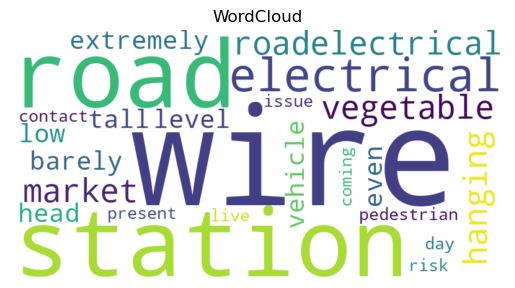

In [105]:
text=df["processed_text"][0]
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud")
plt.show()

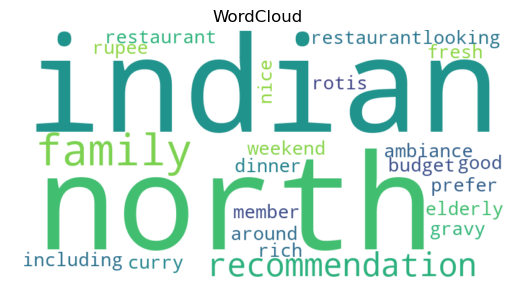

In [106]:
text=df["processed_text"][27]
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud")
plt.show()

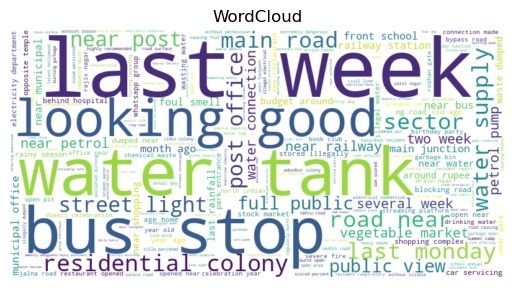

In [109]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(allwords))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud")
plt.show()

In [110]:
allwords

['electrical',
 'wire',
 'station',
 'road',
 'roadelectrical',
 'wire',
 'vegetable',
 'market',
 'station',
 'road',
 'hanging',
 'extremely',
 'low',
 'barely',
 'head',
 'level',
 'tall',
 'vehicle',
 'even',
 'pedestrian',
 'risk',
 'coming',
 'contact',
 'live',
 'wire',
 'issue',
 'present',
 'day',
 'electricity',
 'meter',
 'tampering',
 'reported',
 'mondhaa',
 'resident',
 'mondha',
 'illegally',
 'hooked',
 'direct',
 'wire',
 'main',
 'power',
 'line',
 'bypassing',
 'electricity',
 'meter',
 'causing',
 'voltage',
 'fluctuation',
 'neighbouring',
 'home',
 'serious',
 'safety',
 'legal',
 'violation',
 'water',
 'meter',
 'installed',
 'sector',
 'despite',
 'requestdespite',
 'applying',
 'since',
 'last',
 'monday',
 'ago',
 'water',
 'meter',
 'installed',
 'several',
 'household',
 'sector',
 'water',
 'department',
 'unresponsive',
 'resident',
 'unable',
 'get',
 'official',
 'water',
 'connection',
 'street',
 'light',
 'working',
 'pune',
 'nakaall',
 'street',
 '

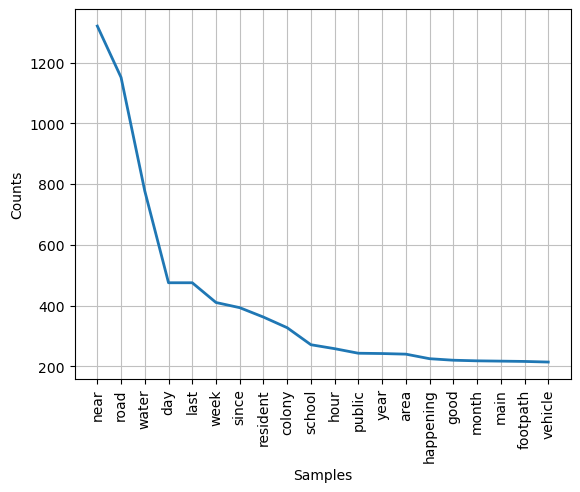

In [112]:
freq_dist = FreqDist(allwords)
freq_dist.plot(20)
plt.show()

In [116]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['processed_text'])
Y = df['Label']

In [119]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [123]:
lr = LogisticRegression()
lr.fit(X_train, Y_train)
Y_pred = lr.predict(X_test)

In [130]:
print("Accuracy of Logistic Regression:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy of Logistic Regression: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       159
           1       1.00      1.00      1.00       241

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [132]:
svc = SVC()
svc.fit(X_train, Y_train)
Y_pred = svc.predict(X_test)
print("SVC Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

SVC Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       159
           1       1.00      1.00      1.00       241

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [135]:
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, Y_train)
Y_pred = rfc.predict(X_test)
print("RFC Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

RFC Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       159
           1       1.00      1.00      1.00       241

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [138]:
nb = MultinomialNB()
nb.fit(X_train, Y_train)
Y_pred = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Naive Bayes Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       159
           1       1.00      1.00      1.00       241

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



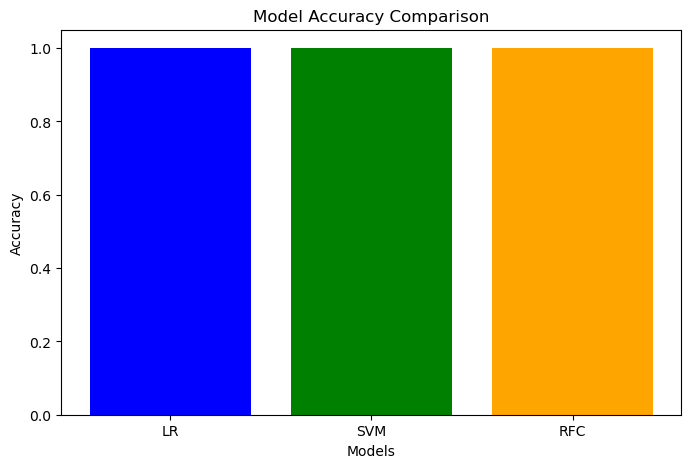

In [142]:
plt.figure(figsize=(8,5))
plt.bar(["LR","SVM","RFC"], [1,1,1], color=['blue', 'green', 'orange'])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [144]:
joblib.dump(svc, "svc_model.pkl")
joblib.dump(rfc, "rfc_model.pkl")
joblib.dump(nb, "nb_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']